# Loss-Conditional PINN — Buckley-Leverett Equation
## 1D Two-Phase Flow in Porous Media

**Architecture:** $F_c(x, t, \log\lambda) \rightarrow s(x,t)$

**Objective:** $\arg\min_\theta \, \mathbb{E}_{\lambda \sim P_\lambda}\, \mathcal{L}\bigl(y,\, F_c(x, \theta, \lambda),\, \lambda\bigr)$

**Key features:**
- Loss weights $\lambda$ are **network inputs**, not learnable parameters or static scalars
- Softmax parameterization converts $\log\lambda$ to normalized loss-component probabilities
- Curriculum learning gradually expands the $\lambda$ sampling range
- Post-training $\lambda$ sweep finds optimal weights without retraining

### How to run
1. In folder `code/`: run `poetry install`, then select the **Poetry environment** as the Jupyter kernel (so `import pinns` resolves).
2. **Device:** the first code cell uses `pinns.device.select_device()` — order is **CUDA** (NVIDIA) → **MPS** (Apple Silicon GPU) → **CPU**. Override with env `PINN_DEVICE=cpu` or `mps` or `cuda`.
3. Execute cells **top-to-bottom** (seeds are fixed).
4. Full training ~90+ min at 300k steps on CPU (usually faster on GPU/MPS). Shorten with `CONFIG['N_EPOCHS']`.
5. Figures are saved under `./results/`.

### Notebook outline
| # | Section |
|---|---------|
| 1 | Setup & configuration |
| 2 | Physical model (Buckley-Leverett) |
| 3 | Reference solution (Rusanov FVM) |
| 4 | Model & lambda sampling |
| 5 | Training data |
| 6 | Loss computation |
| 7 | Training loop |
| 8 | Diagnostics |
| 9 | Lambda sweep & export |

**Thesis experiments (advisor):** recommended benchmark ladder, metrics, and baselines are summarized in [`ADVISOR_BENCHMARKS.md`](ADVISOR_BENCHMARKS.md) (same folder as this notebook).

### Project log

| Date | Change |
|------|--------|
| 2026-04-06 | Notebook restructure: numbered sections, `CONFIG` dict, `savefig` helper, log-log loss plots, figure export to `./results/`, work log & TODO cells |
| 2026-04-06 | `tqdm` in `train_lc_pinn`, `requirements.txt`, `WORKLOG.md` mirror, cleared heavy cell outputs |
| 2026-04-06 | Added `ADVISOR_BENCHMARKS.md` (advisor benchmark suite + evaluation protocol); linked from here and `WORKLOG.md` |
| 2026-04-13 | Core in `pinns/` package (Poetry); `select_device()` for CUDA/MPS/CPU; notebook imports `from pinns...` |

### TODO

- [ ] Baseline PINN (equal fixed weights) — compare against loss-conditional
- [ ] Benchmark ladder from `ADVISOR_BENCHMARKS.md` (2 ODEs + 4 PDEs; Burgers, Allen–Cahn, Helmholtz, Poisson+data, …)
- [ ] Long training run / GPU or cloud if needed
- [ ] Export thesis-quality figures from `./results/`
- [ ] Write-up: connect lambda sweep results to thesis narrative

In [9]:
# --- 1. Setup & configuration ---

import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import time, os
from tqdm.auto import tqdm

from pinns.device import device_info, select_device

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

CONFIG = {
    'N_COLLOCATION': 2000,
    'N_BC':          200,
    'N_IC':          200,
    'N_DATA':        200,
    # 1e-2 caused oscillating loss throughout (too high for BL).
    # 3e-3 = 3× the original default — enough to benefit from warmup without destabilising.
    # 100k steps is sufficient at this LR; extend to 300k if log-log still falling.
    'N_EPOCHS':      100_000,
    'LR':            3e-3,
    # LR warmup: ramp from 0.1× to 1× LR over the first WARMUP_FRAC of training,
    # then cosine-anneal. Set 0.0 to disable (pure cosine, old behaviour).
    'WARMUP_FRAC':   0.3,
    # Hard-example mining: keep top HARD_FRAC highest-residual PDE points each step,
    # resample the rest. Set 0.0 to disable (old behaviour).
    'HARD_FRAC':     0.0,
    'N_LAMBDA_SAMPLES': 4,
    'LOG_EVERY':     5000,
    'CURRICULUM_STEPS': 8000,
    'HIDDEN_DIMS':   [64, 64, 64, 64],
    'RESULTS_DIR':   Path('./results'),
    'CHECKPOINT_PATH': Path('../results/lc_pinn_best.pt'),
    # Identity output (no sigmoid): BL solution lives at s=0 and s=1 exactly —
    # sigmoid gradients vanish near those extremes, causing training to collapse.
    'OUTPUT': 'identity',
}

CONFIG['RESULTS_DIR'].mkdir(parents=True, exist_ok=True)

device = select_device()
torch.manual_seed(42)
np.random.seed(42)

print(f'Device: {device} — {device_info(device)}')


def savefig(name, fig=None):
    """Save current (or given) figure to CONFIG['RESULTS_DIR']/name."""
    target = CONFIG['RESULTS_DIR'] / name
    (fig or plt.gcf()).savefig(target, dpi=150, bbox_inches='tight')


# Set DEBUG = True to use fast settings (~3 min run) for code iteration.
DEBUG = False

if DEBUG:
    from pinns.config import (DEBUG_N_STEPS, DEBUG_N_PDE, DEBUG_N_BC,
                               DEBUG_N_IC, DEBUG_N_DATA, DEBUG_LOG_EVERY)
    CONFIG.update({
        'N_COLLOCATION': DEBUG_N_PDE,
        'N_BC':          DEBUG_N_BC,
        'N_IC':          DEBUG_N_IC,
        'N_DATA':        DEBUG_N_DATA,
        'N_EPOCHS':      DEBUG_N_STEPS,
        'LOG_EVERY':     DEBUG_LOG_EVERY,
    })
    print("DEBUG mode ON — fast settings active.")

print(f'LR={CONFIG["LR"]}  warmup={CONFIG["WARMUP_FRAC"]}  hard_frac={CONFIG["HARD_FRAC"]}  epochs={CONFIG["N_EPOCHS"]:,}')


Device: mps — mps (Apple GPU)
LR=0.003  warmup=0.3  hard_frac=0.0  epochs=100,000


## 2. Physical model — Buckley-Leverett equation

$$\frac{\partial s}{\partial t} + \frac{\partial f(s)}{\partial x} = 0, \qquad f(s) = \frac{s^2}{s^2 + M(1-s)^2}$$

- Domain: $x \in [0, 1],\; t \in [0, 0.5]$
- IC: $s(x, 0) = 0$ (oil-saturated reservoir)
- BC: $s(0, t) = 1$ (water injection at inlet)

In [10]:
# Buckley–Leverett — domain constants (`pinns.config` mirrors `pinns.physics`)
from pinns.config import DEFAULT_DOMAIN

M_RATIO = DEFAULT_DOMAIN.m_ratio
X_MIN, X_MAX = DEFAULT_DOMAIN.x_min, DEFAULT_DOMAIN.x_max
T_MIN, T_MAX = DEFAULT_DOMAIN.t_min, DEFAULT_DOMAIN.t_max
DIM_PHYS = DEFAULT_DOMAIN.dim_phys
DIM_LAMBDA = DEFAULT_DOMAIN.dim_lambda


## 3. Reference solution — Rusanov (Local Lax-Friedrichs) FVM

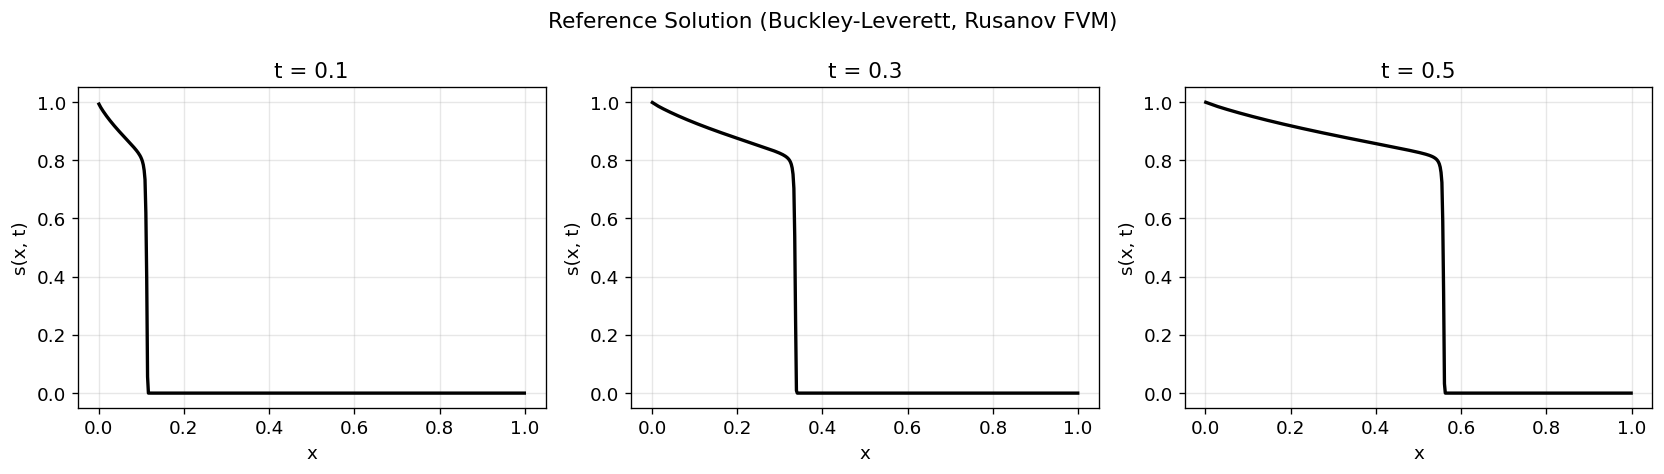

In [11]:
from pinns.reference_fvm import compute_reference_solution

ref_snapshots = compute_reference_solution()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, t_val in zip(axes, [0.1, 0.3, 0.5]):
    if t_val in ref_snapshots:
        xr, sr = ref_snapshots[t_val]
        ax.plot(xr, sr, 'k-', lw=2)
        ax.set_title(f't = {t_val:.1f}')
        ax.set_xlabel('x')
        ax.set_ylabel('s(x, t)')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
plt.suptitle('Reference Solution (Buckley-Leverett, Rusanov FVM)', fontsize=13)
plt.tight_layout()
savefig('fig_reference_fvm.png')
plt.show()


## 4. Model & lambda sampling

Output mode is **`identity`** (no sigmoid) — see `CONFIG['OUTPUT']`. Although sigmoid would bound $s \in (0,1)$ physically, the Buckley–Leverett solution lives at exactly $s=0$ and $s=1$, where sigmoid gradients vanish. This prevents the network from learning the sharp saturation front. Identity output resolves this; physical bounds are enforced instead by the IC/BC loss terms.

In [12]:
from pinns.model import LossConditionalPINN

model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Model parameters: 12,993


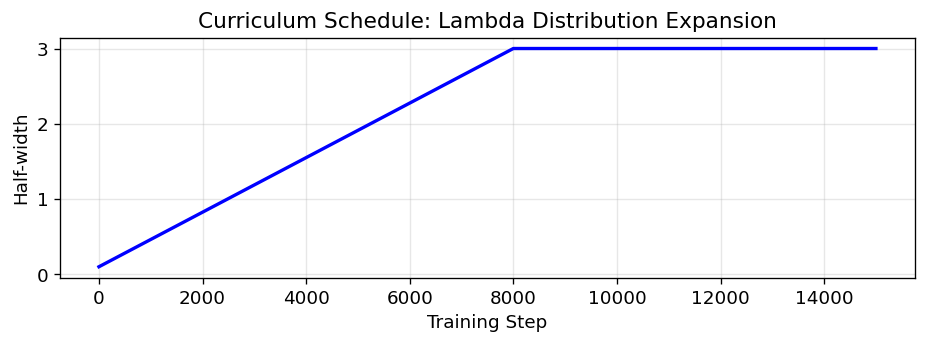

In [13]:
from pinns.lambda_sampler import LambdaSampler

sampler = LambdaSampler(DIM_LAMBDA,
                        curriculum_steps=CONFIG['CURRICULUM_STEPS'],
                        device=device)

steps_vis = np.arange(0, 15001, 100)
hws = [sampler.half_width(int(s)) for s in steps_vis]
plt.figure(figsize=(8, 3))
plt.plot(steps_vis, hws, 'b-', lw=2)
plt.xlabel('Training Step')
plt.ylabel('Half-width')
plt.title('Curriculum Schedule: Lambda Distribution Expansion')
plt.tight_layout()
savefig('fig_curriculum_schedule.png')
plt.show()


## 5. Training data

In [14]:
from pinns.data import generate_training_data

batch = generate_training_data(
    ref_snapshots,
    n_pde=CONFIG['N_COLLOCATION'],
    n_bc=CONFIG['N_BC'],
    n_ic=CONFIG['N_IC'],
    n_data=CONFIG['N_DATA'],
    device=device,
)
for k, v in batch.items():
    print(f'{k:15s}: shape={list(v.shape)}')


coords_pde     : shape=[2000, 2]
coords_bc      : shape=[200, 2]
s_bc           : shape=[200, 1]
coords_ic      : shape=[200, 2]
s_ic           : shape=[200, 1]
coords_data    : shape=[200, 2]
s_data         : shape=[200, 1]


## 6. Loss computation

In [15]:
# Unweighted losses: `pinns.losses.compute_losses` (used inside `train_lc_pinn`)
from pinns.losses import compute_losses  # optional: interactive debugging


## 7. Training loop

In [16]:
from pinns.training import train_lc_pinn


In [ ]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

def make_live_plot_callback(n_epochs, loss_keys_hint=None):
    """
    Returns a callback for train_lc_pinn(on_log=...) that redraws a live
    loss curve in Jupyter every time it is called.

    Usage:
        history = train_lc_pinn(..., on_log=make_live_plot_callback(N_EPOCHS))
    """
    def _callback(history):
        steps = np.array(history['step'])
        if len(steps) < 2:
            return

        keys = [k for k in history if k not in ('step', 'total', 'hw', 'elapsed_sec')]
        mask = steps > 0

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Left: log-log of all loss components
        ax = axes[0]
        ax.plot(np.log10(steps[mask]), np.log10(np.array(history['total'])[mask]),
                'k-', lw=2, label='Total')
        for k in keys:
            ax.plot(np.log10(steps[mask]), np.log10(np.array(history[k])[mask]),
                    '--', alpha=0.75, label=k.upper())
        ax.set_xlabel('log₁₀(step)')
        ax.set_ylabel('log₁₀(loss)')
        ax.set_title(f'Training — step {steps[-1]:,}/{n_epochs:,}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        # Right: semilogy of total loss
        ax = axes[1]
        ax.semilogy(steps, history['total'], 'k-', lw=2)
        ax.set_xlabel('Step')
        ax.set_ylabel('Weighted total loss')
        ax.set_title('Total loss (semilogy)')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return _callback


In [ ]:
history = train_lc_pinn(
    model, sampler, batch,
    device=device,
    n_epochs=CONFIG['N_EPOCHS'],
    lr=CONFIG['LR'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=CONFIG['LOG_EVERY'],
    warmup_frac=CONFIG['WARMUP_FRAC'],
    hard_frac=CONFIG['HARD_FRAC'],
    on_log=make_live_plot_callback(CONFIG['N_EPOCHS']),
)


## 7.5 Equal-weight baseline

Same MLP, same training budget — fixed λ = [0.25, 0.25, 0.25, 0.25] throughout.

In [10]:
from pinns.baseline import FixedWeightPINN, train_fixed_pinn

baseline_model = FixedWeightPINN(DIM_PHYS, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']).to(device)
print(f'Baseline parameters: {sum(p.numel() for p in baseline_model.parameters()):,}')

baseline_history = train_fixed_pinn(
    baseline_model,
    weights=[0.25, 0.25, 0.25, 0.25],
    batch=batch,
    device=device,
    n_epochs=CONFIG['N_EPOCHS'],
    lr=CONFIG['LR'],
    warmup_frac=CONFIG['WARMUP_FRAC'],
    desc='Equal-weight baseline',
)


Baseline parameters: 12,737


Equal-weight baseline: 100%|██████████| 300000/300000 [31:29<00:00, 158.81step/s, L=3.16e-05]

Equal-weight baseline done in 1889s (31.5 min)


## 8. Diagnostics

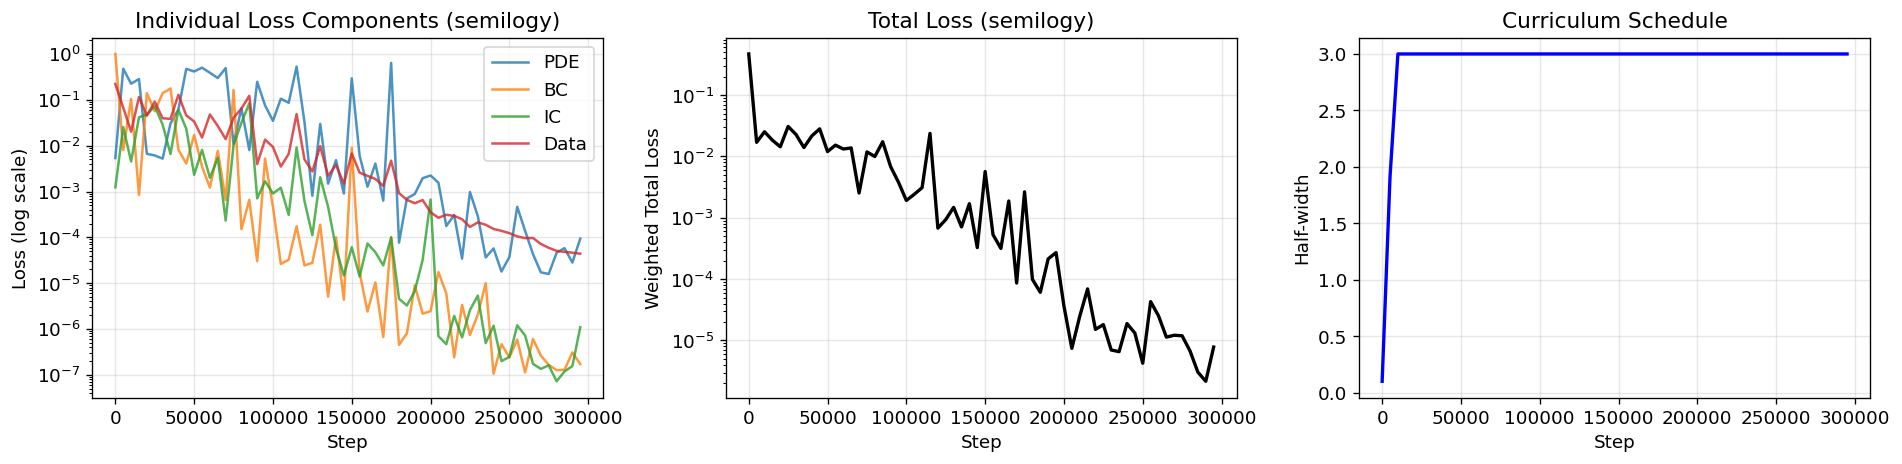

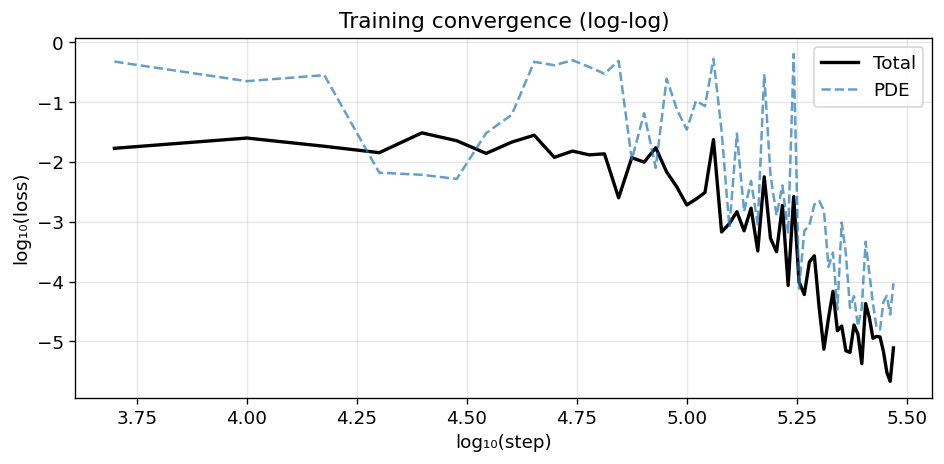

In [11]:
steps_h = np.array(history['step'])
loss_keys = [k for k in history if k not in ('step', 'total', 'hw', 'elapsed_sec')]

# --- semilogy: individual components ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k in loss_keys:
    ax.semilogy(steps_h, history[k], label=k.upper(), alpha=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Individual Loss Components (semilogy)')
ax.legend()

ax = axes[1]
ax.semilogy(steps_h, history['total'], 'k-', lw=2)
ax.set_xlabel('Step')
ax.set_ylabel('Weighted Total Loss')
ax.set_title('Total Loss (semilogy)')

ax = axes[2]
ax.plot(steps_h, history['hw'], 'b-', lw=2)
ax.set_xlabel('Step')
ax.set_ylabel('Half-width')
ax.set_title('Curriculum Schedule')

plt.tight_layout()
savefig('fig_training_semilogy.png')
plt.show()

# --- log-log: all terms (advisor-requested) ---
mask = steps_h > 0
log_s = np.log10(steps_h[mask])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(log_s, np.log10(np.array(history['total'])[mask]), 'k-', lw=2, label='Total')
for k in loss_keys:
    ax.plot(log_s, np.log10(np.array(history[k])[mask]), '--', alpha=0.7, label=k.upper())
ax.set_xlabel('log₁₀(step)')
ax.set_ylabel('log₁₀(loss)')
ax.set_title('Training convergence (log-log)')
ax.legend()
plt.tight_layout()
savefig('fig_training_loglog.png')
plt.show()


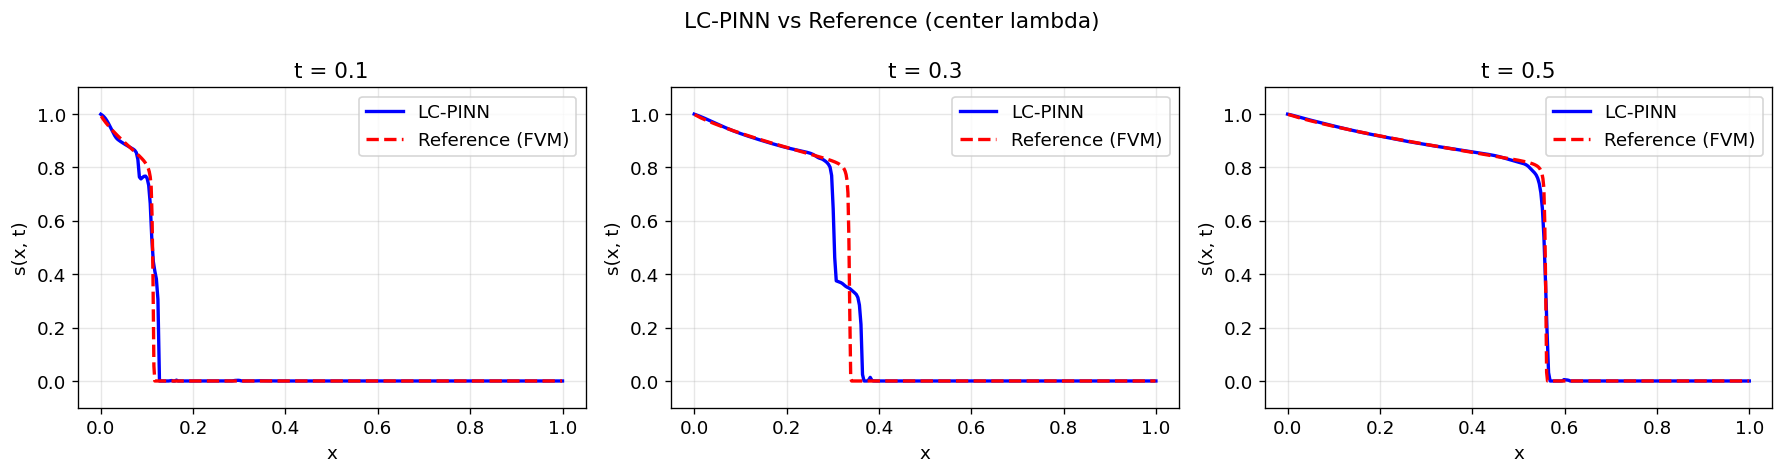

In [12]:
from pinns.inference import predict_solution

model.eval()
x_plot = np.linspace(X_MIN, X_MAX, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_val in zip(axes, [0.1, 0.3, 0.5]):
    s_pred = predict_solution(model, sampler.center, x_plot, t_val, device)
    ax.plot(x_plot, s_pred, 'b-', lw=2, label='LC-PINN')
    if t_val in ref_snapshots:
        xr, sr = ref_snapshots[t_val]
        ax.plot(xr, sr, 'r--', lw=2, label='Reference (FVM)')
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xlabel('x')
    ax.set_ylabel('s(x, t)')
    ax.set_ylim(-0.1, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('LC-PINN vs Reference (center lambda)', fontsize=13)
plt.tight_layout()
savefig('fig_prediction_center_lambda.png')
plt.show()


## 9. Lambda sweep & export

Best log(lambda):     [-2.653  1.066  0.584  2.471]
Best softmax(lambda): [0.0042 0.1749 0.108  0.7129]
Best validation loss: 3.462438e-05


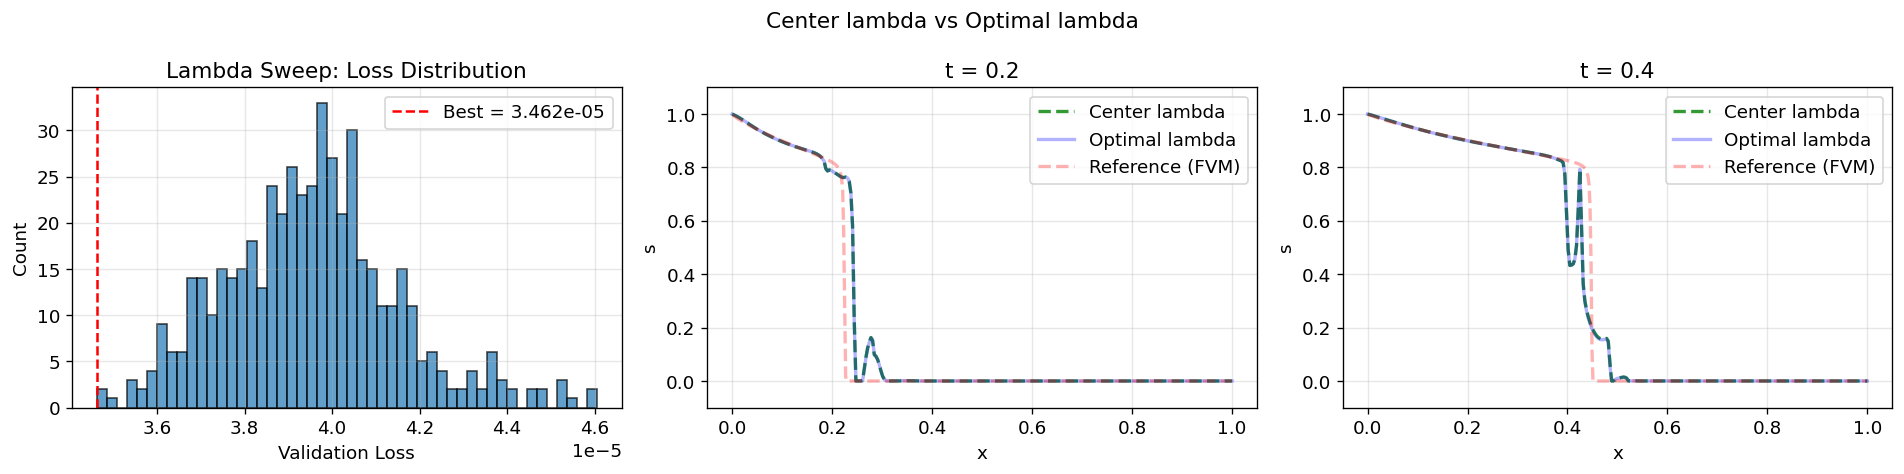

Checkpoint saved to results/lc_pinn_best.pt


In [20]:
from pinns.inference import predict_solution, sweep_lambda

best_ll, best_p, all_vals = sweep_lambda(model, batch, sampler, device=device)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.hist(all_vals, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(min(all_vals), color='r', ls='--', label=f'Best = {min(all_vals):.3e}')
ax.set_xlabel('Validation Loss')
ax.set_ylabel('Count')
ax.set_title('Lambda Sweep: Loss Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

for ax, t_val in zip(axes[1:], [0.2, 0.4]):
    s_center = predict_solution(model, sampler.center, x_plot, t_val, device)
    s_best = predict_solution(model, best_ll, x_plot, t_val, device)
    ax.plot(x_plot, s_center, 'g--', lw=2, label='Center lambda', alpha=0.8)
    ax.plot(x_plot, s_best, 'b-', lw=2, label='Optimal lambda', alpha=0.3)
    if t_val in ref_snapshots:
        xr, sr = ref_snapshots[t_val]
        ax.plot(xr, sr, 'r--', lw=2, label='Reference (FVM)', alpha=0.3)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('s')
    ax.set_ylim(-0.1, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Center lambda vs Optimal lambda', fontsize=13)
plt.tight_layout()
savefig('fig_lambda_sweep.png')
plt.show()

torch.save({
    'model_state_dict': model.state_dict(),
    'best_log_lambda': best_ll,
    'history': history,
}, str(CONFIG['CHECKPOINT_PATH']))
print(f'Checkpoint saved to {CONFIG["CHECKPOINT_PATH"]}')


## 10. LC-PINN vs Baseline comparison

In [ ]:
from pinns.baseline import predict_solution_fixed, evaluate_fixed
from pinns.inference import evaluate_lc_pinn
import numpy as np

model.eval()
x_plot = np.linspace(X_MIN, X_MAX, 300)
t_vals_plot = [0.1, 0.3, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_val in zip(axes, t_vals_plot):
    s_lc = predict_solution(model, best_ll, x_plot, t_val, device)
    xr, sr = ref_snapshots[t_val]
    ax.plot(xr, sr, 'r--', lw=2, label='FVM reference')
    ax.plot(x_plot, s_lc, 'b-', lw=2, label='LC-PINN')
    if 'baseline_model' in dir():
        s_bl = predict_solution_fixed(baseline_model, x_plot, t_val, device)
        ax.plot(x_plot, s_bl, 'g-', lw=1.5, label='Equal-weight baseline', alpha=0.85)
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xlabel('x')
    ax.set_ylabel('s(x, t)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)
plt.suptitle('LC-PINN vs FVM reference', fontsize=13)
plt.tight_layout()
savefig('fig_comparison.png')
plt.show()


In [ ]:
lc_errors = evaluate_lc_pinn(model, best_ll, ref_snapshots, device)
snap_times = sorted(lc_errors.keys())

rows = [("LC-PINN", lc_errors, history)]
if 'baseline_model' in dir():
    bl_errors = evaluate_fixed(baseline_model, ref_snapshots, device)
    rows.append(("Equal-weight baseline", bl_errors, baseline_history))

print(f"{'':22}" + "".join(f"  t={t:.1f}" for t in snap_times) + "   Mean   Train time")
print("-" * 75)
for label, errs, hist in rows:
    vals = [errs[t] for t in snap_times]
    mins = hist['elapsed_sec'] / 60
    print(f"{label:22}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}  {mins:.1f} min")


## 11. Weight-stability & λ robustness

Two questions:
1. **How sensitive are predictions to λ?** — draw 50 random weight vectors, plot prediction ribbon (mean ± 1σ) vs FVM reference.
2. **LC-PINN at equal weights** — plug λ = [0.25, 0.25, 0.25, 0.25] directly into the trained LC-PINN and compare rel-L2 to the equal-weight baseline trained from scratch.

In [ ]:
from pinns.inference import predict_solution_averaged, evaluate_lc_pinn_averaged
import numpy as np

model.eval()
N_SAMPLES = 50
x_plot = np.linspace(X_MIN, X_MAX, 300)
t_vals_plot = [0.1, 0.3, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_val in zip(axes, t_vals_plot):
    mean_pred, std_pred = predict_solution_averaged(
        model, sampler, N_SAMPLES, x_plot, t_val, device
    )
    xr, sr = ref_snapshots[t_val]
    ax.plot(xr, sr, 'r--', lw=2, label='FVM reference')
    ax.plot(x_plot, mean_pred, 'b-', lw=2, label=f'LC-PINN mean (n={N_SAMPLES})')
    ax.fill_between(
        x_plot,
        mean_pred - std_pred,
        mean_pred + std_pred,
        alpha=0.25, color='blue', label='±1σ across λ'
    )
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xlabel('x')
    ax.set_ylabel('s(x, t)')
    ax.set_ylim(-0.1, 1.15)
    ax.legend(fontsize=9)
plt.suptitle('Prediction ribbon: mean ± 1σ over 50 random λ vectors', fontsize=13)
plt.tight_layout()
savefig('fig_lambda_ribbon.png')
plt.show()


In [ ]:
# LC-PINN queried at equal weights vs equal-weight baseline trained from scratch
equal_log_lambda = torch.log(
    torch.tensor([0.25, 0.25, 0.25, 0.25], dtype=torch.float32, device=device)
)

lc_eq_errors  = evaluate_lc_pinn(model, equal_log_lambda, ref_snapshots, device)
lc_avg_errors = evaluate_lc_pinn_averaged(model, sampler, 50, ref_snapshots, device)
# lc_errors and bl_errors already computed in section 10 (cell above)

snap_times_11 = sorted(lc_eq_errors.keys())
header = f"{'Method':30}" + "".join(f'  t={t:.1f}' for t in snap_times_11) + '   Mean'
print(header)
print('-' * len(header))
for label, errs in [
    ('FW baseline (equal weights)',  bl_errors),
    ('LC-PINN @ equal weights',      lc_eq_errors),
    ('LC-PINN @ best λ (sweep)',     lc_errors),
    ('LC-PINN @ avg 50 λ',          lc_avg_errors),
]:
    vals = [errs[t] for t in snap_times_11]
    print(f'{label:30}' + "".join(f'  {v:.4f}' for v in vals) + f'  {np.mean(vals):.4f}')


### 11b. Does the sweep find something better than the sampler center?

Verify the best λ from `sweep_lambda` is genuinely different from the prior center `[log 1, log 10, log 10, log 1]` — i.e., the model actually learned a preference.

In [ ]:
import torch.nn.functional as F

center_log_lambda = sampler.center
center_p = torch.softmax(center_log_lambda, dim=0)
best_p   = torch.softmax(best_ll, dim=0)
cos_sim  = F.cosine_similarity(best_p.unsqueeze(0), center_p.unsqueeze(0)).item()

center_errors = evaluate_lc_pinn(model, center_log_lambda, ref_snapshots, device)
# lc_errors = LC-PINN @ sweep best (computed in section 10)

print(f'Sampler center  λ (softmax): {center_p.cpu().numpy().round(4)}')
print(f'Sweep best      λ (softmax): {best_p.cpu().numpy().round(4)}')
print(f'Cosine similarity:           {cos_sim:.4f}  (1.0 = identical direction)')
print()
snap_times_c = sorted(center_errors.keys())
header = f"{'Method':30}" + "".join(f'  t={t:.1f}' for t in snap_times_c) + '   Mean'
print(header)
print('-' * len(header))
for label, errs in [
    ('LC-PINN @ sampler center', center_errors),
    ('LC-PINN @ sweep best',     lc_errors),
]:
    vals = [errs[t] for t in snap_times_c]
    print(f'{label:30}' + "".join(f'  {v:.4f}' for v in vals) + f'  {np.mean(vals):.4f}')


In [16]:
print("Saved figures:")
for p in sorted(CONFIG['RESULTS_DIR'].glob('fig_*.png')):
    print(f'  {p}')

Saved figures:
  results/fig_comparison.png
  results/fig_curriculum_schedule.png
  results/fig_lambda_sweep.png
  results/fig_prediction_center_lambda.png
  results/fig_reference_fvm.png
  results/fig_training_loglog.png
  results/fig_training_semilogy.png


## 12. Checkpoint comparison

Side-by-side evaluation of all saved checkpoints on the FVM reference.
Checkpoints live in `results/checkpoints/` — see `README.md` there for details.


In [ ]:
from pinns.model import LossConditionalPINN
from pinns.inference import evaluate_lc_pinn, predict_solution
import torch, numpy as np, matplotlib.pyplot as plt

CHECKPOINTS = {
    "v1: lr=1e-3, 300k steps, no warmup (Mar 22)":      "../checkpoints/bl_lr1e3_300k_mar22.pt",
    "v2: lr=3e-3, 300k steps, warmup=0.3 (Apr 15)":     "../checkpoints/bl_lr3e3_300k_warmup_apr15.pt",
}

results = {}
for label, path in CHECKPOINTS.items():
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = LossConditionalPINN(DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'],
                            output=CONFIG['OUTPUT']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    ll = ckpt['best_log_lambda'].to(device)
    errors = evaluate_lc_pinn(m, ll, ref_snapshots, device)
    results[label] = {
        'model': m,
        'log_lambda': ll,
        'errors': errors,
        'lambda_softmax': torch.softmax(ll, dim=0).cpu().numpy().round(3),
    }

# Use keys from evaluate_lc_pinn (excludes t=0.0)
snap_times = sorted(next(iter(results.values()))['errors'].keys())

# --- Error table ---
header = f"{'Checkpoint':48}" + "".join(f"  t={t:.1f}" for t in snap_times) + "   Mean   lambda (softmax)"
print(header)
print("-" * len(header))
for label, r in results.items():
    vals = [r['errors'][t] for t in snap_times]
    print(f"{label:48}" + "".join(f"  {v:.4f}" for v in vals) +
          f"  {np.mean(vals):.4f}   {r['lambda_softmax']}")

# --- Prediction plots ---
t_plot = snap_times[:3]
fig, axes = plt.subplots(len(CHECKPOINTS), 3, figsize=(15, 4 * len(CHECKPOINTS)))
colors = ['steelblue', 'darkorange']
for row, (label, r) in enumerate(results.items()):
    for col, t_val in enumerate(t_plot):
        ax = axes[row, col]
        xr, sr = ref_snapshots[t_val]
        s_pred = predict_solution(r['model'], r['log_lambda'],
                                  np.linspace(X_MIN, X_MAX, 300), t_val, device)
        ax.plot(xr, sr, 'r--', lw=2, label='FVM reference')
        ax.plot(np.linspace(X_MIN, X_MAX, 300), s_pred,
                color=colors[row], lw=2, label=label.split(':')[0])
        ax.set_title(f"{label.split(':')[0]}  —  t={t_val:.1f}")
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlabel('x'); ax.set_ylabel('s(x,t)')
        ax.legend(fontsize=8)

plt.suptitle('Checkpoint comparison — LC-PINN vs FVM reference', fontsize=13)
plt.tight_layout()
savefig('fig_checkpoint_comparison.png')
plt.show()


## 13. Overnight experiments

Six ablation runs, each self-contained. Run cells sequentially — no retraining needed for sections above.

| Tag | LR | Warmup | Hard frac | Sampling | Steps | Checkpoint |
|-----|----|--------|-----------|----------|-------|------------|
| v1 ✅ | 1e-3 | none | 0 | logspace | 300k | `bl_lr1e3_300k_mar22.pt` |
| v2 ✅ | 3e-3 | 0.3 | 0 | logspace | 300k | `bl_lr3e3_300k_warmup_apr15.pt` |
| v3 | 1e-3 | none | 0.3 | logspace | 300k | `bl_v3_lr1e3_hard03_300k.pt` |
| v4 | 1e-3 | none | 0 | simplex | 300k | `bl_v4_lr1e3_simplex_300k.pt` |
| v5 | 1e-3 | none | 0.3 | simplex | 300k | `bl_v5_lr1e3_hard03_simplex_300k.pt` |
| v6 | 1e-3 | none | 0 | logspace | 500k | `bl_v6_lr1e3_500k.pt` |
| v7 | 1e-3 | 0.3 | 0 | logspace | 300k | `bl_v7_lr1e3_warmup03_300k.pt` |
| v8 | 3e-3 | none | 0 | logspace | 300k | `bl_v8_lr3e3_nowarmup_300k.pt` |


In [17]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np, torch, os

def make_overnight_callback(tag, desc, exp_cfg, model, ckpt_path, n_epochs, save_every=50_000):
    """
    Live-updating loss plot + periodic checkpoint saves every save_every steps.
    Captures model via closure so it can save mid-run.
    """
    os.makedirs('checkpoints', exist_ok=True)

    def _callback(history):
        step = history['step'][-1]

        # ── periodic save ──────────────────────────────────────────────────────
        if step > 0 and step % save_every == 0:
            interim = ckpt_path.replace('.pt', f'_step{step//1000}k.pt')
            torch.save({'model_state_dict': model.state_dict(), 'history': history}, interim)

        # ── live plot ─────────────────────────────────────────────────────────
        if len(history['step']) < 2:
            return
        steps  = np.array(history['step'])
        keys   = [k for k in history if k not in ('step', 'total', 'hw', 'elapsed_sec')]
        mask   = steps > 0
        pct    = 100 * step / n_epochs
        elapsed = history.get('elapsed_sec', [0])
        elapsed_min = elapsed / 60 if isinstance(elapsed, (int, float)) else 0

        clear_output(wait=True)

        # config banner
        print('=' * 68)
        print(f'  {tag}: {desc}')
        print(f'  lr={exp_cfg["lr"]}  warmup={exp_cfg["warmup"]}  '
              f'hard_frac={exp_cfg["hard"]}  mode={exp_cfg["mode"]}  '
              f'steps={exp_cfg["steps"]:,}')
        print(f'  Progress: step {step:,}/{n_epochs:,}  ({pct:.1f}%)')
        print('=' * 68)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        ax = axes[0]
        ax.plot(np.log10(steps[mask]),
                np.log10(np.array(history['total'])[mask]),
                'k-', lw=2, label='Total')
        for k in keys:
            ax.plot(np.log10(steps[mask]),
                    np.log10(np.array(history[k])[mask]),
                    '--', alpha=0.75, label=k.upper())
        ax.set_xlabel('log₁₀(step)')
        ax.set_ylabel('log₁₀(loss)')
        ax.set_title(f'{tag}: {desc}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.semilogy(steps, history['total'], 'k-', lw=2)
        ax.set_xlabel('Step'); ax.set_ylabel('Total loss')
        ax.set_title('Total loss')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return _callback


In [18]:
# Pre-flight: verify everything needed for overnight runs is in scope.
# Run this AFTER cells 1-5 (Setup, Domain, FVM reference, Model, Training data).
assert 'batch'         in dir(), "batch not defined — run Section 5 first"
assert 'ref_snapshots' in dir(), "ref_snapshots not defined — run Section 3 first"
assert 'device'        in dir(), "device not defined — run Section 1 first"
import os
os.makedirs('checkpoints', exist_ok=True)
print("Pre-flight OK — ready to run overnight experiments.")
print(f"Device: {device}")
print(f"Checkpoints will be saved to: ../checkpoints/")


Pre-flight OK — ready to run overnight experiments.
Device: mps
Checkpoints will be saved to: checkpoints/


  v3: Hard-example mining
  lr=0.001  warmup=0.0  hard_frac=0.3  mode=logspace  steps=300,000
  Progress: step 290,000/300,000  (96.7%)


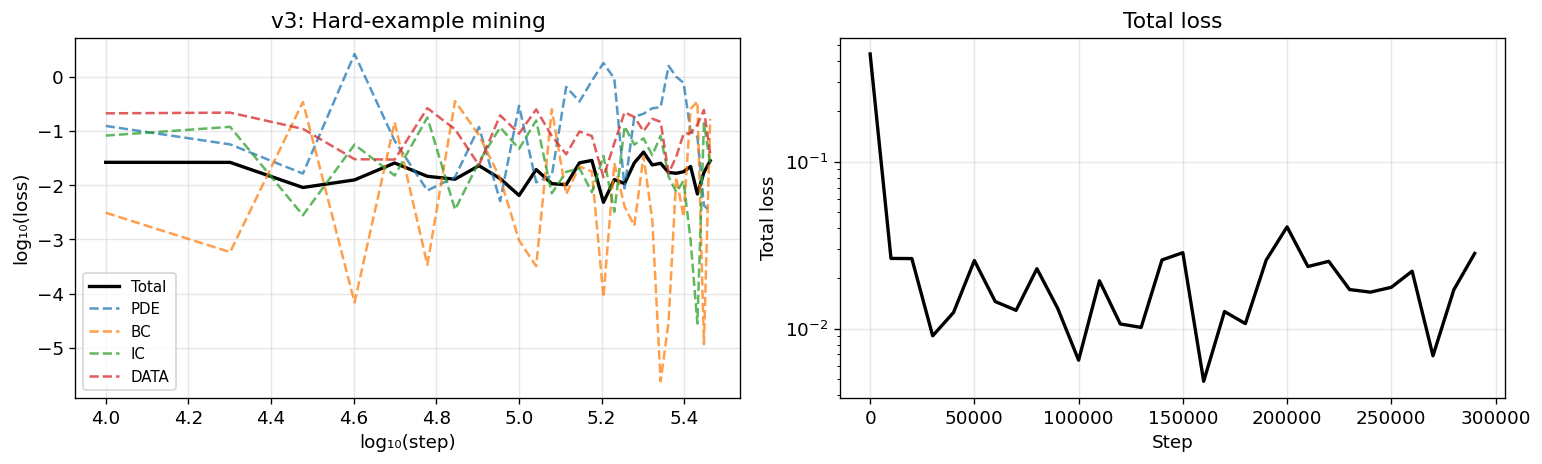

Training: 100%|██████████| 300000/300000 [1:38:50<00:00, 50.59step/s, L=2.82e-02, hw=3.00]



Training complete in 5931s (98.8 min)
Model saved → checkpoints/bl_v3_lr1e3_hard03_300k.pt
Best log(lambda):     [-2.902  4.575  4.116  2.566]
Best softmax(lambda): [3.000e-04 5.660e-01 3.577e-01 7.590e-02]
Best validation loss: 7.453904e-03
Sweep best loss: 7.454e-03
Best λ (softmax): [0.    0.566 0.358 0.076]
Rel-L2: t=0.1=0.2581 t=0.2=0.2298 t=0.3=0.2110 t=0.4=0.1748 t=0.5=0.1225  mean=0.1992
Checkpoint updated with best_log_lambda → checkpoints/bl_v3_lr1e3_hard03_300k.pt


In [19]:
# ==================================================================
# V3: Hard-example mining
# lr=0.001  warmup=0.0  hard_frac=0.3
# mode=logspace  steps=300,000
# checkpoint → ../checkpoints/bl_v3_lr1e3_hard03_300k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.001, warmup=0.0, hard=0.3,
            mode='logspace', steps=300000)
_CKPT = '../checkpoints/bl_v3_lr1e3_hard03_300k.pt'

v3_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v3_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v3: Hard-example mining")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v3_history = train_lc_pinn(
    v3_model, v3_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v3', 'Hard-example mining', _EXP, v3_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v3_model.state_dict(),
    'history': v3_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v3_model, batch, v3_sampler, device=device)
    torch.save({
        'model_state_dict': v3_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v3_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v3_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


  v4: Simplex λ sampling
  lr=0.001  warmup=0.0  hard_frac=0.0  mode=simplex  steps=300,000
  Progress: step 290,000/300,000  (96.7%)


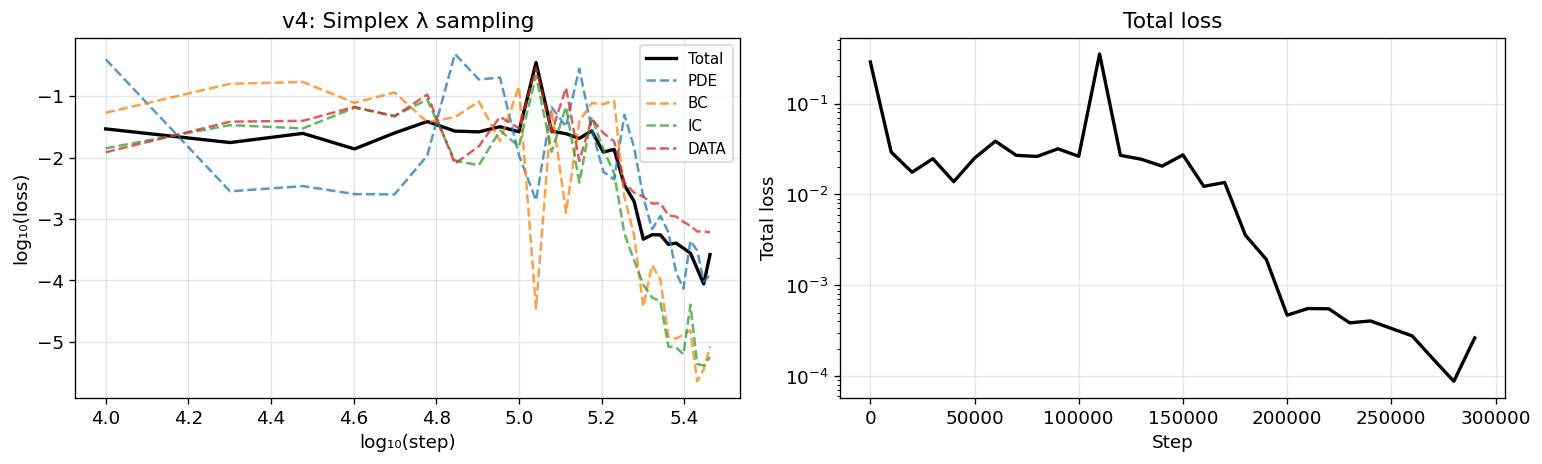

Training: 100%|██████████| 300000/300000 [1:40:52<00:00, 49.57step/s, L=2.63e-04, hw=3.00]



Training complete in 6052s (100.9 min)
Model saved → checkpoints/bl_v4_lr1e3_simplex_300k.pt
Best log(lambda):     [-9.33  -3.966 -1.614 -0.246]
Best softmax(lambda): [1.000e-04 1.890e-02 1.991e-01 7.819e-01]
Best validation loss: 3.540162e-04
Sweep best loss: 3.540e-04
Best λ (softmax): [0.    0.019 0.199 0.782]
Rel-L2: t=0.1=0.1911 t=0.2=0.1478 t=0.3=0.1333 t=0.4=0.1066 t=0.5=0.0391  mean=0.1236
Checkpoint updated with best_log_lambda → checkpoints/bl_v4_lr1e3_simplex_300k.pt


In [20]:
# ==================================================================
# V4: Simplex λ sampling
# lr=0.001  warmup=0.0  hard_frac=0.0
# mode=simplex  steps=300,000
# checkpoint → ../checkpoints/bl_v4_lr1e3_simplex_300k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.001, warmup=0.0, hard=0.0,
            mode='simplex', steps=300000)
_CKPT = '../checkpoints/bl_v4_lr1e3_simplex_300k.pt'

v4_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v4_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v4: Simplex λ sampling")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v4_history = train_lc_pinn(
    v4_model, v4_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v4', 'Simplex λ sampling', _EXP, v4_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v4_model.state_dict(),
    'history': v4_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v4_model, batch, v4_sampler, device=device)
    torch.save({
        'model_state_dict': v4_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v4_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v4_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


  v5: Hard mining + simplex (combined)
  lr=0.001  warmup=0.0  hard_frac=0.3  mode=simplex  steps=300,000
  Progress: step 290,000/300,000  (96.7%)


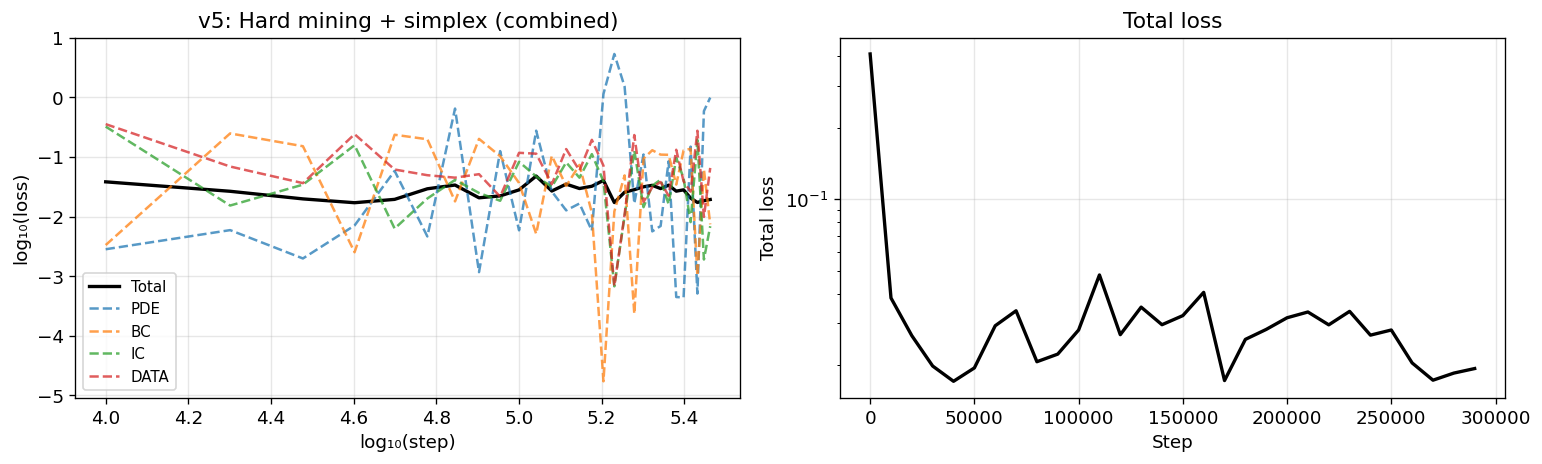

Training: 100%|██████████| 300000/300000 [1:47:31<00:00, 46.50step/s, L=1.93e-02, hw=3.00]



Training complete in 6452s (107.5 min)
Model saved → checkpoints/bl_v5_lr1e3_hard03_simplex_300k.pt
Best log(lambda):     [-9.983 -1.002 -1.317 -1.008]
Best softmax(lambda): [0.     0.3671 0.268  0.3648]
Best validation loss: 5.842709e-03
Sweep best loss: 5.843e-03
Best λ (softmax): [0.    0.367 0.268 0.365]
Rel-L2: t=0.1=0.2320 t=0.2=0.2102 t=0.3=0.1655 t=0.4=0.1233 t=0.5=0.0911  mean=0.1644
Checkpoint updated with best_log_lambda → checkpoints/bl_v5_lr1e3_hard03_simplex_300k.pt


In [21]:
# ==================================================================
# V5: Hard mining + simplex (combined)
# lr=0.001  warmup=0.0  hard_frac=0.3
# mode=simplex  steps=300,000
# checkpoint → ../checkpoints/bl_v5_lr1e3_hard03_simplex_300k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.001, warmup=0.0, hard=0.3,
            mode='simplex', steps=300000)
_CKPT = '../checkpoints/bl_v5_lr1e3_hard03_simplex_300k.pt'

v5_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v5_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v5: Hard mining + simplex (combined)")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v5_history = train_lc_pinn(
    v5_model, v5_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v5', 'Hard mining + simplex (combined)', _EXP, v5_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v5_model.state_dict(),
    'history': v5_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v5_model, batch, v5_sampler, device=device)
    torch.save({
        'model_state_dict': v5_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v5_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v5_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


  v6: Longer training (500k steps)
  lr=0.001  warmup=0.0  hard_frac=0.0  mode=logspace  steps=500,000
  Progress: step 490,000/500,000  (98.0%)


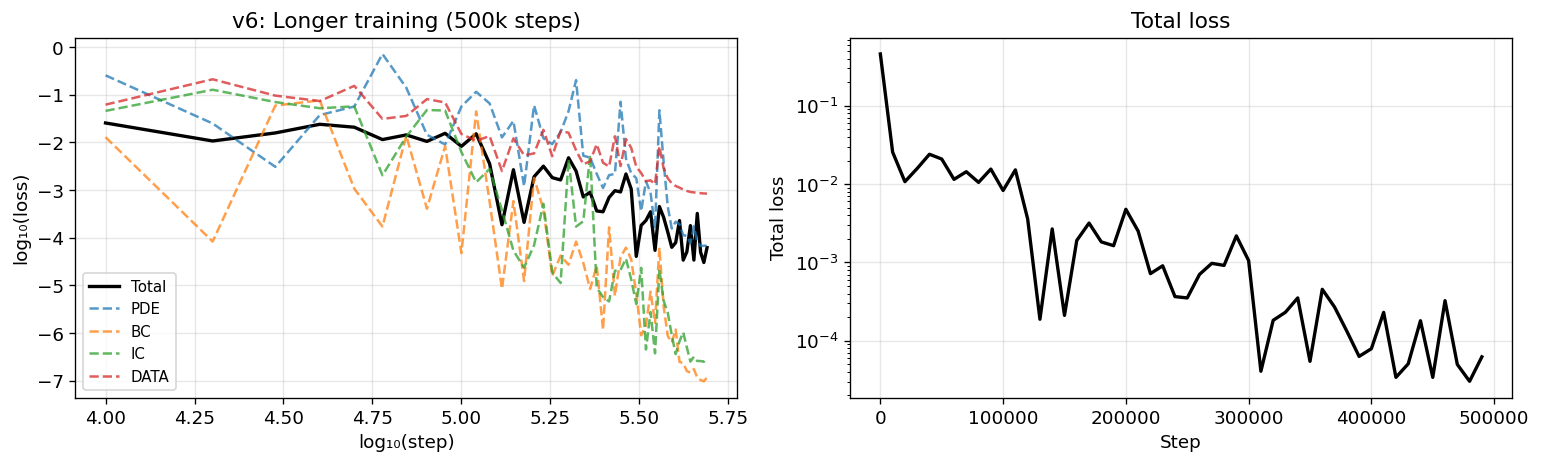

Training: 100%|██████████| 500000/500000 [2:31:47<00:00, 54.90step/s, L=6.23e-05, hw=3.00]



Training complete in 9107s (151.8 min)
Model saved → checkpoints/bl_v6_lr1e3_500k.pt
Best log(lambda):     [-2.96   1.803  1.688  2.81 ]
Best softmax(lambda): [0.0018 0.2156 0.1922 0.5904]
Best validation loss: 8.373001e-04
Sweep best loss: 8.373e-04
Best λ (softmax): [0.002 0.216 0.192 0.59 ]
Rel-L2: t=0.1=0.2644 t=0.2=0.2836 t=0.3=0.2138 t=0.4=0.1695 t=0.5=0.0582  mean=0.1979
Checkpoint updated with best_log_lambda → checkpoints/bl_v6_lr1e3_500k.pt


In [22]:
# ==================================================================
# V6: Longer training (500k steps)
# lr=0.001  warmup=0.0  hard_frac=0.0
# mode=logspace  steps=500,000
# checkpoint → ../checkpoints/bl_v6_lr1e3_500k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.001, warmup=0.0, hard=0.0,
            mode='logspace', steps=500000)
_CKPT = '../checkpoints/bl_v6_lr1e3_500k.pt'

v6_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v6_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v6: Longer training (500k steps)")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v6_history = train_lc_pinn(
    v6_model, v6_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v6', 'Longer training (500k steps)', _EXP, v6_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v6_model.state_dict(),
    'history': v6_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v6_model, batch, v6_sampler, device=device)
    torch.save({
        'model_state_dict': v6_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v6_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v6_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


  v7: Warmup ablation (lr=1e-3 + warmup)
  lr=0.001  warmup=0.3  hard_frac=0.0  mode=logspace  steps=300,000
  Progress: step 290,000/300,000  (96.7%)


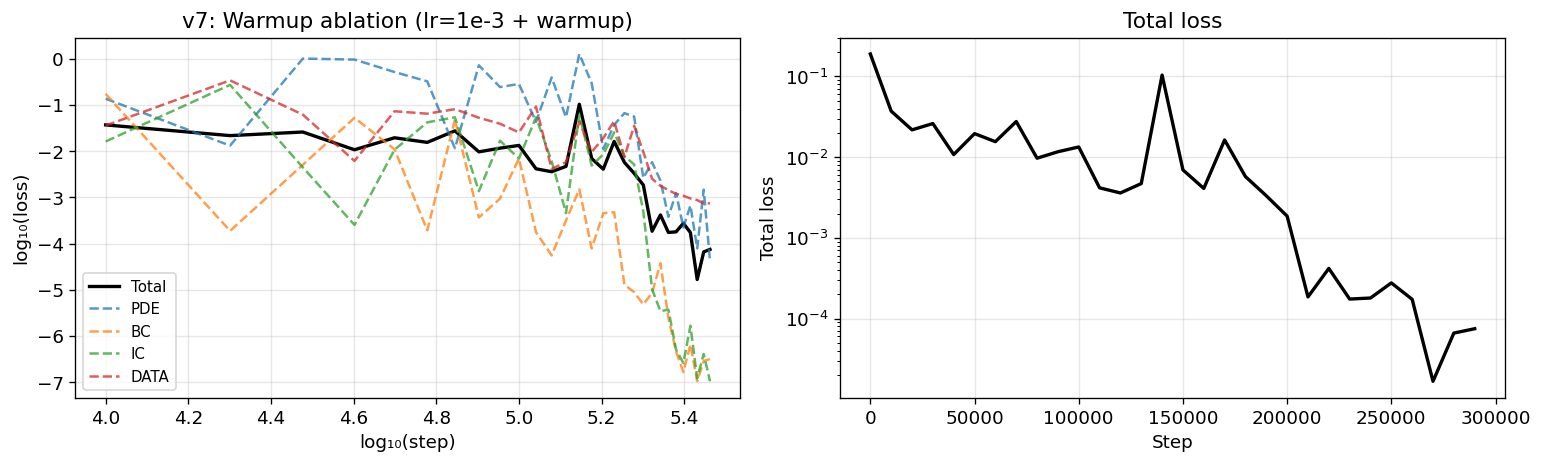

Training: 100%|██████████| 300000/300000 [1:29:44<00:00, 55.72step/s, L=7.48e-05, hw=3.00]



Training complete in 5384s (89.7 min)
Model saved → checkpoints/bl_v7_lr1e3_warmup03_300k.pt
Best log(lambda):     [-2.943  3.9    0.31   2.49 ]
Best softmax(lambda): [0.0008 0.7857 0.0217 0.1918]
Best validation loss: 6.608895e-04
Sweep best loss: 6.609e-04
Best λ (softmax): [0.001 0.786 0.022 0.192]
Rel-L2: t=0.1=0.0808 t=0.2=0.1765 t=0.3=0.2199 t=0.4=0.1619 t=0.5=0.0540  mean=0.1386
Checkpoint updated with best_log_lambda → checkpoints/bl_v7_lr1e3_warmup03_300k.pt


In [23]:
# ==================================================================
# V7: Warmup ablation (lr=1e-3 + warmup)
# lr=0.001  warmup=0.3  hard_frac=0.0
# mode=logspace  steps=300,000
# checkpoint → ../checkpoints/bl_v7_lr1e3_warmup03_300k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.001, warmup=0.3, hard=0.0,
            mode='logspace', steps=300000)
_CKPT = '../checkpoints/bl_v7_lr1e3_warmup03_300k.pt'

v7_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v7_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v7: Warmup ablation (lr=1e-3 + warmup)")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v7_history = train_lc_pinn(
    v7_model, v7_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v7', 'Warmup ablation (lr=1e-3 + warmup)', _EXP, v7_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v7_model.state_dict(),
    'history': v7_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v7_model, batch, v7_sampler, device=device)
    torch.save({
        'model_state_dict': v7_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v7_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v7_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


  v8: Higher LR, no warmup ablation
  lr=0.003  warmup=0.0  hard_frac=0.0  mode=logspace  steps=300,000
  Progress: step 290,000/300,000  (96.7%)


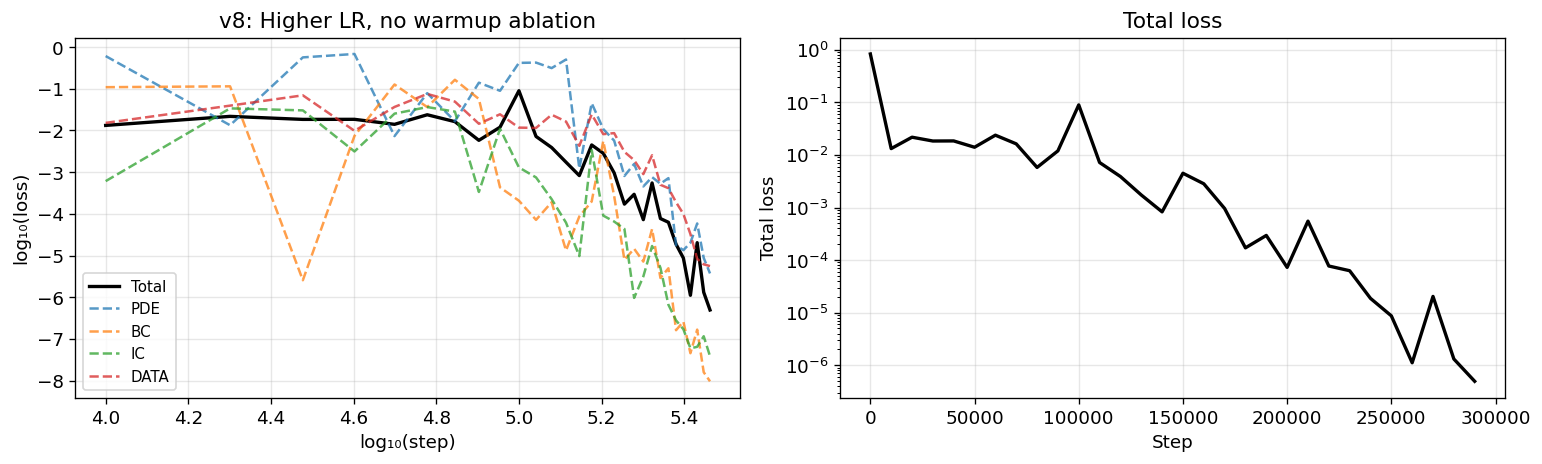

Training: 100%|██████████| 300000/300000 [1:29:00<00:00, 56.17step/s, L=4.93e-07, hw=3.00]



Training complete in 5341s (89.0 min)
Model saved → checkpoints/bl_v8_lr3e3_nowarmup_300k.pt
Best log(lambda):     [-2.941  0.47   0.678  2.512]
Best softmax(lambda): [0.0033 0.1003 0.1235 0.773 ]
Best validation loss: 5.467964e-06
Sweep best loss: 5.468e-06
Best λ (softmax): [0.003 0.1   0.123 0.773]
Rel-L2: t=0.1=0.2446 t=0.2=0.1704 t=0.3=0.1718 t=0.4=0.1400 t=0.5=0.0582  mean=0.1570
Checkpoint updated with best_log_lambda → checkpoints/bl_v8_lr3e3_nowarmup_300k.pt


In [24]:
# ==================================================================
# V8: Higher LR, no warmup ablation
# lr=0.003  warmup=0.0  hard_frac=0.0
# mode=logspace  steps=300,000
# checkpoint → ../checkpoints/bl_v8_lr3e3_nowarmup_300k.pt
# ==================================================================

from pinns.model import LossConditionalPINN
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda, evaluate_lc_pinn

_EXP = dict(lr=0.003, warmup=0.0, hard=0.0,
            mode='logspace', steps=300000)
_CKPT = '../checkpoints/bl_v8_lr3e3_nowarmup_300k.pt'

v8_model = LossConditionalPINN(
    DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'], output=CONFIG['OUTPUT']
).to(device)
v8_sampler = LambdaSampler(
    DIM_LAMBDA,
    curriculum_steps=CONFIG['CURRICULUM_STEPS'],
    device=device,
    mode=_EXP['mode'],
)

print(f"Starting v8: Higher LR, no warmup ablation")
print(f"  lr={_EXP['lr']}  warmup={_EXP['warmup']}  hard_frac={_EXP['hard']}  "
      f"mode={_EXP['mode']}  steps={_EXP['steps']:,}")

v8_history = train_lc_pinn(
    v8_model, v8_sampler, batch, device=device,
    n_epochs=_EXP['steps'],
    lr=_EXP['lr'],
    n_lambda_samples=CONFIG['N_LAMBDA_SAMPLES'],
    log_every=10_000,
    warmup_frac=_EXP['warmup'],
    hard_frac=_EXP['hard'],
    on_log=make_overnight_callback(
        'v8', 'Higher LR, no warmup ablation', _EXP, v8_model, _CKPT, _EXP['steps']
    ),
)

# Save immediately after training (before sweep, in case sweep fails)
torch.save({
    'model_state_dict': v8_model.state_dict(),
    'history': v8_history,
    'config': _EXP,
}, _CKPT)
print(f"Model saved → {_CKPT}")

# Lambda sweep + final save with best_log_lambda
try:
    _best_ll, _best_p, _all_vals = sweep_lambda(v8_model, batch, v8_sampler, device=device)
    torch.save({
        'model_state_dict': v8_model.state_dict(),
        'best_log_lambda': _best_ll,
        'history': v8_history,
        'config': _EXP,
    }, _CKPT)
    _errors = evaluate_lc_pinn(v8_model, _best_ll, ref_snapshots, device)
    _snap   = sorted(_errors.keys())
    _vals   = [_errors[t] for t in _snap]
    print(f"Sweep best loss: {min(_all_vals):.3e}")
    print(f"Best λ (softmax): {torch.softmax(_best_ll, dim=0).cpu().numpy().round(3)}")
    print(f"Rel-L2: {' '.join(f't={t:.1f}={v:.4f}' for t,v in zip(_snap,_vals))}  mean={float(np.mean(_vals)):.4f}")
    print(f"Checkpoint updated with best_log_lambda → {_CKPT}")
except Exception as e:
    print(f"Sweep failed ({e}) — model still saved without best_log_lambda")


### 13b. All-runs comparison table

In [25]:
# ── All-runs comparison (run after overnight experiments complete) ─────────────
from pinns.model import LossConditionalPINN
from pinns.inference import evaluate_lc_pinn
import torch, numpy as np, os

ALL_CHECKPOINTS = {
    'v1: lr=1e-3, 300k, no warmup (Mar 22)': '../checkpoints/bl_lr1e3_300k_mar22.pt',
    'v2: lr=3e-3, 300k, warmup=0.3 (Apr 15)': '../checkpoints/bl_lr3e3_300k_warmup_apr15.pt',
    'v3: lr=1e-3, 300k, hard_frac=0.3': '../checkpoints/bl_v3_lr1e3_hard03_300k.pt',
    'v4: lr=1e-3, 300k, simplex': '../checkpoints/bl_v4_lr1e3_simplex_300k.pt',
    'v5: lr=1e-3, 300k, hard+simplex': '../checkpoints/bl_v5_lr1e3_hard03_simplex_300k.pt',
    'v6: lr=1e-3, 500k': '../checkpoints/bl_v6_lr1e3_500k.pt',
    'v7: lr=1e-3, 300k, warmup=0.3': '../checkpoints/bl_v7_lr1e3_warmup03_300k.pt',
    'v8: lr=3e-3, 300k, no warmup': '../checkpoints/bl_v8_lr3e3_nowarmup_300k.pt',
}

snap_times = None
rows = []
for label, path in ALL_CHECKPOINTS.items():
    if not os.path.exists(path):
        print(f"MISSING: {path} — skipping")
        continue
    ckpt = torch.load(path, map_location=device, weights_only=False)
    m = LossConditionalPINN(DIM_PHYS, DIM_LAMBDA, CONFIG['HIDDEN_DIMS'],
                            output=CONFIG['OUTPUT']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    ll = ckpt.get('best_log_lambda')
    if ll is None:
        print(f"No best_log_lambda in {path} — skipping")
        continue
    ll = ll.to(device)
    errors = evaluate_lc_pinn(m, ll, ref_snapshots, device)
    if snap_times is None:
        snap_times = sorted(errors.keys())
    lam = torch.softmax(ll, dim=0).cpu().numpy().round(3)
    vals = [errors[t] for t in snap_times]
    rows.append((label, vals, lam))

rows.sort(key=lambda x: float(np.mean(x[1])))   # sort by mean rel-L2

header = f"{'':<48}" + ''.join(f'  t={t:.1f}' for t in snap_times) + '   Mean   λ [pde,bc,ic,data]'
print(header)
print('-' * len(header))
for label, vals, lam in rows:
    print(f'{label:<48}' + ''.join(f'  {v:.4f}' for v in vals) +
          f'  {np.mean(vals):.4f}   {lam}')


                                                  t=0.1  t=0.2  t=0.3  t=0.4  t=0.5   Mean   λ [pde,bc,ic,data]
---------------------------------------------------------------------------------------------------------------
v4: lr=1e-3, 300k, simplex                        0.1911  0.1478  0.1333  0.1066  0.0391  0.1236   [0.    0.019 0.199 0.782]
v1: lr=1e-3, 300k, no warmup (Mar 22)             0.0682  0.1929  0.1704  0.1597  0.0347  0.1252   [0.001 0.667 0.112 0.22 ]
v7: lr=1e-3, 300k, warmup=0.3                     0.0808  0.1765  0.2199  0.1619  0.0540  0.1386   [0.001 0.786 0.022 0.192]
v8: lr=3e-3, 300k, no warmup                      0.2446  0.1704  0.1718  0.1400  0.0582  0.1570   [0.003 0.1   0.123 0.773]
v2: lr=3e-3, 300k, warmup=0.3 (Apr 15)            0.2108  0.2396  0.1411  0.1533  0.0575  0.1605   [0.    0.862 0.047 0.091]
v5: lr=1e-3, 300k, hard+simplex                   0.2320  0.2102  0.1655  0.1233  0.0911  0.1644   [0.    0.367 0.268 0.365]
v6: lr=1e-3, 500k         

## 14. LC-PINN (v1) vs Equal-weight baseline — self-contained comparison

Loads the best LC-PINN checkpoint (v1: `bl_lr1e3_300k_mar22.pt`) and a 300 k-step equal-weight baseline trained at the same config.
The baseline is cached to `checkpoints/baseline_equal_300k_lr1e3.pt` so it only trains once.

In [ ]:
# ── Section 14: self-contained comparison (survives kernel restarts) ────────
# Requires: device, CONFIG, DIM_PHYS, DIM_LAMBDA, ref_snapshots, batch, savefig
# (run Sections 1-5 first, or just run from top-to-bottom)

import os, torch, numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn, predict_solution_fixed, evaluate_fixed
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import (evaluate_lc_pinn, predict_solution,
                              predict_solution_averaged, evaluate_lc_pinn_averaged,
                              sweep_lambda)

HIDDEN_DIMS    = CONFIG['HIDDEN_DIMS']
OUTPUT         = CONFIG['OUTPUT']
LC_CKPT        = '../checkpoints/bl_lr1e3_300k_mar22.pt'
BL_CKPT        = '../checkpoints/baseline_equal_300k_lr1e3.pt'
BL_LR          = 1e-3
BL_STEPS       = 300_000

# ── 1. Load LC-PINN v1 ───────────────────────────────────────────────────────
lc_ckpt = torch.load(LC_CKPT, map_location=device, weights_only=False)
lc_model = LossConditionalPINN(DIM_PHYS, DIM_LAMBDA, HIDDEN_DIMS, output=OUTPUT).to(device)
lc_model.load_state_dict(lc_ckpt['model_state_dict'])
lc_model.eval()
lc_best_ll = lc_ckpt['best_log_lambda'].to(device)
print(f"LC-PINN v1 loaded from {LC_CKPT}")
print(f"  Best λ (softmax): {torch.softmax(lc_best_ll, dim=0).cpu().numpy().round(3)}")

lc_sampler = LambdaSampler(DIM_LAMBDA, curriculum_steps=CONFIG['CURRICULUM_STEPS'], device=device)

# ── 2. Load or train equal-weight baseline (lr=1e-3, 300k, no warmup) ───────
if os.path.exists(BL_CKPT):
    bl_ckpt = torch.load(BL_CKPT, map_location=device, weights_only=False)
    bl_model = FixedWeightPINN(DIM_PHYS, HIDDEN_DIMS, output=OUTPUT).to(device)
    bl_model.load_state_dict(bl_ckpt['model_state_dict'])
    bl_model.eval()
    bl_elapsed = bl_ckpt.get('elapsed_sec', 0)
    print(f"Baseline loaded from {BL_CKPT}  (trained {bl_elapsed/60:.1f} min)")
else:
    print(f"Training equal-weight baseline: lr={BL_LR}, steps={BL_STEPS:,}, no warmup ...")
    bl_model = FixedWeightPINN(DIM_PHYS, HIDDEN_DIMS, output=OUTPUT).to(device)
    bl_history = train_fixed_pinn(
        bl_model, weights=[0.25, 0.25, 0.25, 0.25], batch=batch,
        device=device, n_epochs=BL_STEPS, lr=BL_LR, warmup_frac=0.0,
        desc='Equal-weight baseline (v1-matched)',
    )
    bl_elapsed = bl_history['elapsed_sec']
    torch.save({'model_state_dict': bl_model.state_dict(),
                'elapsed_sec': bl_elapsed,
                'config': dict(lr=BL_LR, steps=BL_STEPS, warmup=0.0, weights=[0.25]*4)},
               BL_CKPT)
    print(f"Baseline saved → {BL_CKPT}")

# ── 3. Evaluate ──────────────────────────────────────────────────────────────
x_plot      = np.linspace(X_MIN, X_MAX, 300)
snap_times  = sorted(t for t in ref_snapshots.keys() if t > 0)

lc_errors       = evaluate_lc_pinn(lc_model, lc_best_ll, ref_snapshots, device)
bl_errors       = evaluate_fixed(bl_model, ref_snapshots, device)
equal_ll        = torch.log(torch.tensor([0.25, 0.25, 0.25, 0.25], dtype=torch.float32, device=device))
lc_eq_errors    = evaluate_lc_pinn(lc_model, equal_ll, ref_snapshots, device)
lc_avg_errors   = evaluate_lc_pinn_averaged(lc_model, lc_sampler, 50, ref_snapshots, device)
center_errors   = evaluate_lc_pinn(lc_model, lc_sampler.center, ref_snapshots, device)

# center vs best cosine sim
best_p   = torch.softmax(lc_best_ll, dim=0)
center_p = torch.softmax(lc_sampler.center, dim=0)
cos_sim  = F.cosine_similarity(best_p.unsqueeze(0), center_p.unsqueeze(0)).item()

# ── 4. Print tables ──────────────────────────────────────────────────────────
print()
print("=== Section 10/11: LC-PINN (v1) vs Equal-weight baseline ===")
header = f"{'Method':30}" + "".join(f"  t={t:.1f}" for t in snap_times) + "   Mean"
print(header)
print("-" * len(header))
for label, errs in [
    ("FW baseline (equal weights)", bl_errors),
    ("LC-PINN @ equal weights",     lc_eq_errors),
    ("LC-PINN @ sampler center",    center_errors),
    ("LC-PINN @ best λ (sweep)",    lc_errors),
    ("LC-PINN @ avg 50 λ",         lc_avg_errors),
]:
    vals = [errs[t] for t in snap_times]
    print(f"{label:30}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}")

print()
print(f"Sampler center  λ: {center_p.cpu().numpy().round(3)}")
print(f"Sweep best      λ: {best_p.cpu().numpy().round(3)}")
print(f"Cosine similarity: {cos_sim:.4f}  (1.0 = identical direction)")

# ── 5. Comparison figure ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_val in zip(axes, [0.1, 0.3, 0.5]):
    xr, sr = ref_snapshots[t_val]
    s_lc = predict_solution(lc_model, lc_best_ll, x_plot, t_val, device)
    s_bl = predict_solution_fixed(bl_model, x_plot, t_val, device)
    ax.plot(xr, sr, 'r--', lw=2, label='FVM reference')
    ax.plot(x_plot, s_lc, 'b-', lw=2, label='LC-PINN (v1)')
    ax.plot(x_plot, s_bl, 'g-', lw=1.5, label='Equal-weight baseline', alpha=0.85)
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xlabel('x'); ax.set_ylabel('s(x, t)')
    ax.set_ylim(-0.05, 1.1); ax.legend(fontsize=9)
plt.suptitle('LC-PINN (v1) vs Equal-weight baseline vs FVM', fontsize=13)
plt.tight_layout()
savefig('fig_comparison.png')
plt.show()

# ── 6. Lambda ribbon figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t_val in zip(axes, [0.1, 0.3, 0.5]):
    mean_pred, std_pred = predict_solution_averaged(lc_model, lc_sampler, 50, x_plot, t_val, device)
    xr, sr = ref_snapshots[t_val]
    ax.plot(xr, sr, 'r--', lw=2, label='FVM reference')
    ax.plot(x_plot, mean_pred, 'b-', lw=2, label='LC-PINN mean (n=50)')
    ax.fill_between(x_plot, mean_pred - std_pred, mean_pred + std_pred,
                    alpha=0.25, color='blue', label='±1σ across λ')
    ax.set_title(f't = {t_val:.1f}')
    ax.set_xlabel('x'); ax.set_ylabel('s(x, t)')
    ax.set_ylim(-0.1, 1.15); ax.legend(fontsize=9)
plt.suptitle('Prediction ribbon: mean ± 1σ over 50 random λ vectors (v1)', fontsize=13)
plt.tight_layout()
savefig('fig_lambda_ribbon.png')
plt.show()
